In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [ ]:
aapl= pd.read_csv('../data/aapl_data.csv', index_col=0, parse_dates=True)

C:\Users\naman\AppData\Local\Temp\ipykernel_28584\525985505.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  aapl= pd.read_csv('../data/aapl_data.csv', index_col=0, parse_dates=True)


In [3]:
aapl.head()

,Date,Close,High,Low,Open,Volume
0,2014-01-02,17.140657,17.261513,17.106261,17.219679,234684800
1,2014-01-03,16.764153,17.158325,16.747108,17.132296,392467600
2,2014-01-06,16.855568,16.944504,16.535457,16.654763,412610800
3,2014-01-07,16.735027,16.918478,16.669332,16.867658,317209200
4,2014-01-08,16.841002,16.906076,16.693187,16.696904,258529600


In [4]:
print(f"APPL shape: {aapl.shape}")


APPL shape: (3057, 6)


In [5]:
aapl["log_return"] = np.log(aapl["Close"] / aapl["Close"].shift(1))

In [6]:
aapl["rolling_volatility"] = aapl["log_return"].rolling(window=30).std() * np.sqrt(252)

In [7]:
aapl["hl_spread"] = aapl["High"] - aapl["Low"]

In [8]:
aapl["volume_change"] = aapl["Volume"].pct_change()

In [9]:
aapl.describe()

,Close,High,Low,Open,Volume,log_return,rolling_volatility,hl_spread,volume_change
count,3057.000000,3057.000000,3057.000000,3057.000000,3.057000e+03,3056.000000,3027.000000,3057.000000,3056.000000
mean,101.140904,102.148840,100.044628,101.057127,1.222825e+08,0.000895,0.258674,2.104212,0.051409
std,76.730264,77.486474,75.913462,76.665854,8.306699e+07,0.017816,0.114398,2.154357,0.364692
min,15.487428,15.541656,15.294368,15.344879,1.791060e+07,-0.137708,0.080444,0.100380,-0.830093
25%,29.069784,29.351120,28.946971,29.174729,6.641680e+07,-0.007070,0.185833,0.471669,-0.176770
50%,67.164780,67.950034,66.415708,66.978700,9.962530e+07,0.000978,0.231829,1.401863,-0.018660
75%,166.155701,167.807684,164.710996,166.387015,1.525312e+08,0.009817,0.296175,3.170490,0.198605
max,285.922455,288.350192,283.035157,285.932471,1.065523e+09,0.142617,0.956475,28.595372,3.771993


In [10]:
aapl.isnull().sum()

Date                   0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
log_return             1
rolling_volatility    30
hl_spread              0
volume_change          1
dtype: int64

In [11]:
aapl["log_return"]= aapl["log_return"].bfill()
aapl["rolling_volatility"] = aapl["rolling_volatility"].bfill()
aapl["volume_change"] = aapl["volume_change"].bfill()

In [12]:
aapl.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_return',
       'rolling_volatility', 'hl_spread', 'volume_change'],
      dtype='str')

In [13]:
aapl.to_csv('../data/aapl_data_enhanced.csv', index=False)

## AAPL Stationary Test

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(aapl["log_return"].dropna())

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("Result        : Stationary")
else:
    print("Result        : Non-Stationary")

ADF Statistic : -18.154424591552328
p-value       : 2.4709133681369336e-30
Result        : Stationary


## AAPL ACF OF RETURNS

<Figure size 1000x500 with 0 Axes>

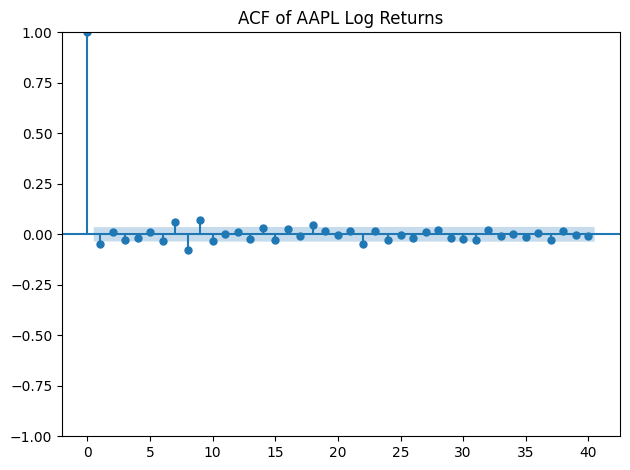

In [21]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    aapl["log_return"].dropna(),
    lags=40
)

plt.title("ACF of AAPL Log Returns")

plt.tight_layout()
plt.show()

## AAPL PACF OF RETURNS

<Figure size 1000x500 with 0 Axes>

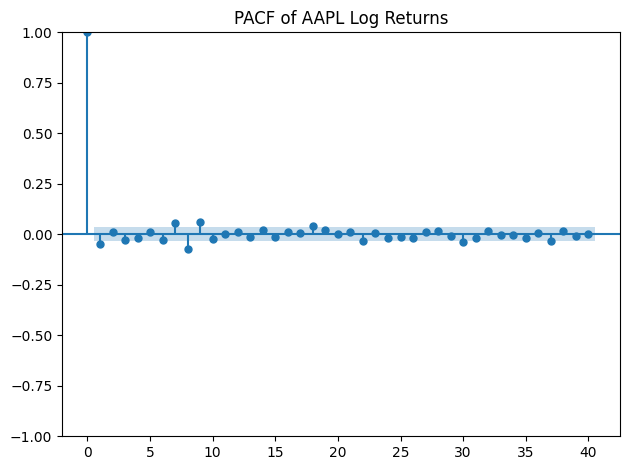

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))

plot_pacf(
    aapl["log_return"].dropna(),
    lags=40
)

plt.title("PACF of AAPL Log Returns")

plt.tight_layout()
plt.show()

## AAPL ARCH LM TEST

In [16]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(aapl["log_return"].dropna())

print("LM Statistic :", arch_test[0])
print("p-value      :", arch_test[1])

if arch_test[1] < 0.05:
    print("ARCH Effects Present")
else:
    print("No ARCH Effects")

LM Statistic : 399.8897485634355
p-value      : 9.935869121729762e-80
ARCH Effects Present


## AAPL GARCH(1,1) MODEL

In [17]:
from arch import arch_model

# Scale returns for numerical stability
returns = aapl["log_return"].dropna() * 100

# Build model
garch_model = arch_model(
    returns,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

# Fit model
garch_fit = garch_model.fit()

# Summary
print(garch_fit.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 1772776376.4404755
Iteration:      2,   Func. Count:     11,   Neg. LLF: 6940.595253127178
Iteration:      3,   Func. Count:     17,   Neg. LLF: 5946.7913293076945
Iteration:      4,   Func. Count:     22,   Neg. LLF: 5867.693639464996
Iteration:      5,   Func. Count:     27,   Neg. LLF: 6168.837186149058
Iteration:      6,   Func. Count:     32,   Neg. LLF: 5865.959447800415
Iteration:      7,   Func. Count:     37,   Neg. LLF: 5825.461512725725
Iteration:      8,   Func. Count:     41,   Neg. LLF: 5825.108601231271
Iteration:      9,   Func. Count:     45,   Neg. LLF: 5825.062268764688
Iteration:     10,   Func. Count:     49,   Neg. LLF: 5825.055792355169
Iteration:     11,   Func. Count:     53,   Neg. LLF: 5825.054532312512
Iteration:     12,   Func. Count:     57,   Neg. LLF: 5825.054529204699
Iteration:     13,   Func. Count:     60,   Neg. LLF: 5825.054529204395
Optimization terminated successfully    (Exit mode 0)
        

## AAPL CONDITIONAL VOLATILITY PLOT

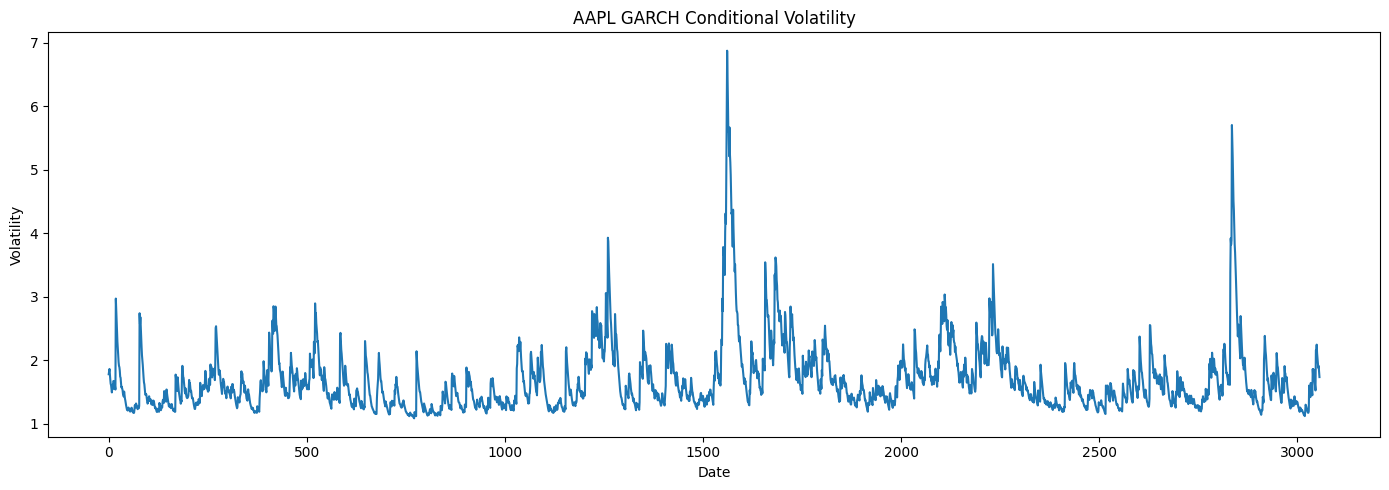

In [18]:
plt.figure(figsize=(14,5))

plt.plot(
    aapl.index[-len(garch_fit.conditional_volatility):],
    garch_fit.conditional_volatility
)

plt.title("AAPL GARCH Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()
plt.show()

## ACTUAL RETURNS vs GARCH VOLATILITY

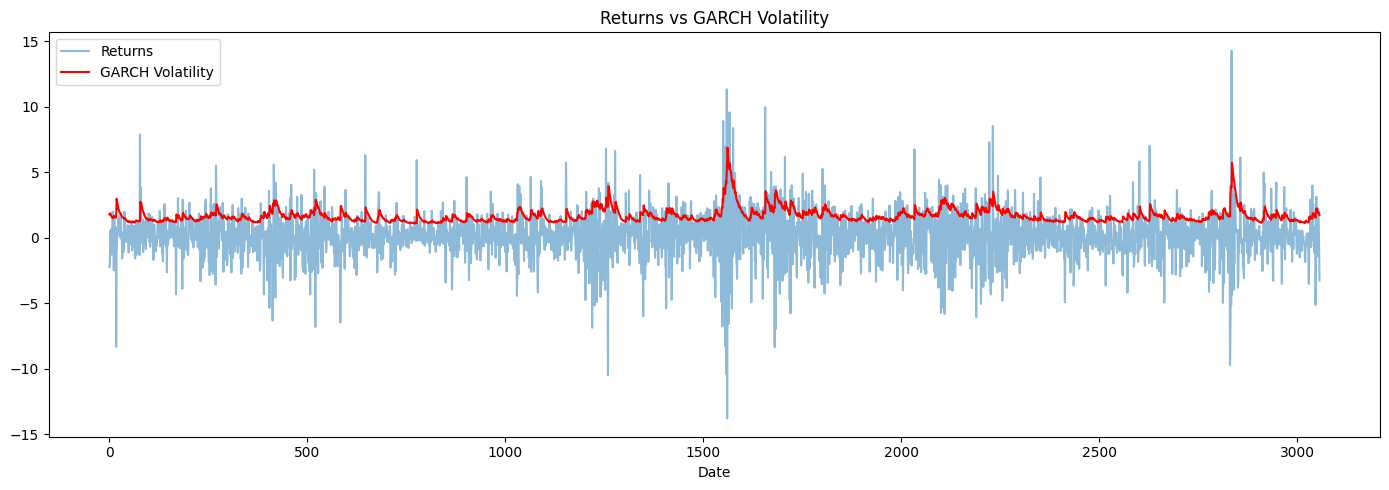

In [19]:
plt.figure(figsize=(14,5))

plt.plot(
    aapl.index[-len(returns):],
    returns,
    alpha=0.5,
    label="Returns"
)

plt.plot(
    aapl.index[-len(garch_fit.conditional_volatility):],
    garch_fit.conditional_volatility,
    color='red',
    label="GARCH Volatility"
)

plt.title("Returns vs GARCH Volatility")
plt.xlabel("Date")

plt.legend()

plt.tight_layout()
plt.show()

## VOLATILITY FORECAST

In [20]:
forecast = garch_fit.forecast(horizon=5)

print("Next 5 Day Volatility Forecast:")
print(forecast.variance.iloc[-1])

Next 5 Day Volatility Forecast:
h.1    3.746535
h.2    3.710900
h.3    3.677098
h.4    3.645034
h.5    3.614618
Name: 3056, dtype: float64
